<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 Edible Vs Poisonous Mushrooms :</font></h3>
    


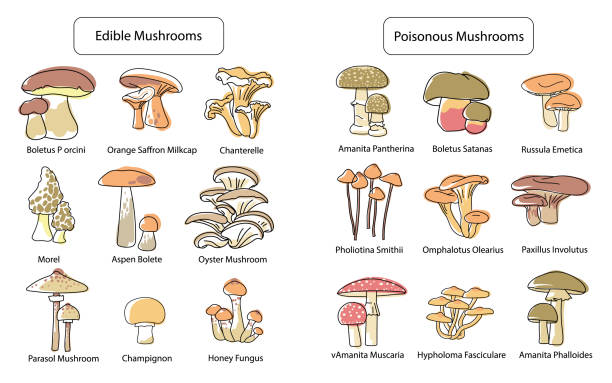

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 About The Competition :</font></h3>
    
**Task**: To develop a model that can classify mushrooms as edible ('e') or poisonous ('p') using a set of physical attributes provided in the dataset.

**Dataset**: Training Dataset (train.csv): Contains features along with the target variable, indicating whether each mushroom is edible or poisonous.Test Dataset (test.csv): Contains the features but requires predictions for whether the mushrooms are edible or poisonous.Additional Information:
    
**Evaluation**: The performance of the model is evaluated using the Matthews correlation coefficient (MCC), a metric that balances true and false positives and negatives, providing a measure of the quality of binary classifications.

The dataset was generated from a deep learning model trained on the UCI Mushroom dataset.

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">Importing Libraries</h1>  
     
</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import lightgbm as lgb
import gc

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">Evalaution Metric</h1>  
     
</div>

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: lightgrey; font-size:100%; text-align:left">

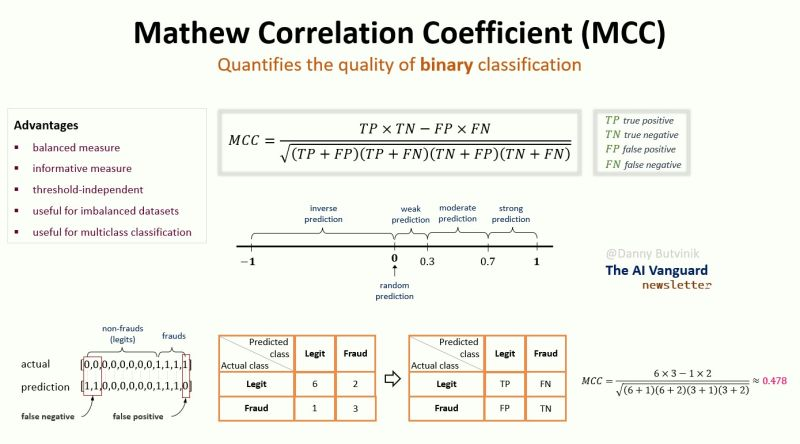

    
      

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🎇🌭Loading  Dataset ♒🌊</h1>  
     
</div>

In [ ]:
df_sub=pd.read_csv("/kaggle/input/playground-series-s4e8/sample_submission.csv")
df_train=pd.read_csv("/kaggle/input/playground-series-s4e8/train.csv")
df_test=pd.read_csv("/kaggle/input/playground-series-s4e8/test.csv")

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: grey; padding: 10px; border-radius: 10px; border: 7px solid cyan; width: 95%;">
  <span style="font-weight: bold; color: blue; animation: pulse 2s infinite;">📉Check </span>
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> on Data  📊</span> 
</p>

In [ ]:
df_train.head()

In [ ]:
df_test.head()

In [ ]:
df_test.shape,df_train.shape

In [ ]:
df_train = df_train.drop(columns=['id'])
df_test = df_test.drop(columns=['id'])

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>Data Talks :</font></h3>
    
**Intial Drop** : Drop Column ID....🎃
    
**Train & Test Distribution** : Looks Heavy no of rows 🎆    
    
**About Feature Columns** : We have 21 and 22 columns in which we can see, lots of features have missing value 🎭

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: grey; padding: 10px; border-radius: 10px; border: 7px solid cyan; width: 95%;">
  <span style="font-weight: bold; color: blue; animation: pulse 2s infinite;">📉Checking  </span>
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> Distribution of categorical features  📊</span> 
</p>

In [ ]:
df_train.info()

In [ ]:
categorical_columns = df_train.select_dtypes(include=['object']).columns
unique_values = {col: df_train[col].nunique() for col in categorical_columns}
for col, unique_count in unique_values.items():
    print(f"{col}: {unique_count} unique values")
    
gc.collect()

In [ ]:
categorical_columns = df_test.select_dtypes(include=['object']).columns
unique_values = {col: df_test[col].nunique() for col in categorical_columns}
for col, unique_count in unique_values.items():
    print(f"{col}: {unique_count} unique values")
    
gc.collect()

In [ ]:
df_test.columns

In [ ]:
df_train.columns

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: black; padding: 20px; border-radius: 20px; border: 7px solid cyan; width: 95%;">
  <span style="font-weight: bold; color: blue; animation: pulse 2s infinite;">📉Exploratory</span>
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> Data Analysis(EDA)  📊</span> 
</p>

In [ ]:
import seaborn as sns

In [ ]:
missing_train = df_train.isna().mean() * 100
missing_test = df_test.isna().mean() * 100

print("Columns in df_train with more than 10% missing values:")
print(missing_train[missing_train > 0])

print("\nColumns in df_test with more than 10% missing values:")
print(missing_test[missing_test > 0])

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>Data Talks :</font></h3>
    
**Common Columns:** Both df_train and df_test share the same columns with more than 10% missing values.
    
**High Missing Values:** The columns stem-root, veil-type, veil-color, and spore-print-color have a very high percentage of missing values, exceeding 80% in both datasets..🎃
    
**Moderate Missing Values:** The columns cap-surface, gill-attachment, gill-spacing, and stem-surface have moderate missing values, ranging from approximately 16% to 63%. 🎭

In [ ]:
missing_values = df_train.isnull().mean() * 100
missing_values = missing_values[missing_values >0]
missing_values = missing_values.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Percentage of Missing Values')
plt.title('Missing Values Distribution in df_train')
plt.show()

In [ ]:
!pip install dython

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
import category_encoders as ce

missing_threshold = 0.95

high_missing_columns = df_train.columns[df_train.isnull().mean() > missing_threshold]

df_train = df_train.drop(columns=high_missing_columns)
df_test = df_test.drop(columns=high_missing_columns)
target = 'class'

for column in df_train.columns:
    if df_train[column].isnull().any():      
        if df_train[column].dtype == 'object':
            mode_value = df_train[column].mode()[0]
            df_train[column].fillna(mode_value, inplace=True)
            df_test[column].fillna(mode_value, inplace=True)     
        else:
            median_value = df_train[column].median()
            df_train[column].fillna(median_value, inplace=True)
            df_test[column].fillna(median_value, inplace=True)

In [ ]:
from dython.nominal import associations

associations_df = associations(df_train[:10000], nominal_columns='all', plot=False)
corr_matrix = associations_df['corr']
plt.figure(figsize=(20, 8))
plt.gcf().set_facecolor('#FFFDD0') 
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix including Categorical Features')
plt.show()

In [ ]:
import plotly.express as px
df_train1 = df_train[:10000].copy()

feature_counts = df_train1.groupby(['cap-shape', 'cap-color']).size().reset_index(name='count')
fig = px.sunburst(feature_counts, path=['cap-shape', 'cap-color'], values='count',
                 color='count', color_continuous_scale='Viridis',
                 title='Sunburst Chart of Cap Shape and Cap Color Distribution')

fig.update_layout(title_text='Sunburst Chart of Cap Shape and Cap Color Distribution',
                  title_x=0.5,width=900,height=600)  
fig.show()

In [ ]:
import plotly.graph_objects as go

flow_data = df_train1.groupby(['cap-shape', 'cap-color']).size().reset_index(name='count')
labels = list(pd.concat([flow_data['cap-shape'], flow_data['cap-color']]).unique())
label_map = {label: idx for idx, label in enumerate(labels)}

sources = flow_data['cap-shape'].map(label_map).tolist()
targets = flow_data['cap-color'].map(label_map).tolist()
values = flow_data['count'].tolist()


fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(
    title_text='Sankey Chart of Cap Shape to Cap Color Flow',
    title_x=0.5,  
    width=1000,   
    height=600 
)
fig.show()

In [ ]:
feature_counts = df_train1.groupby(['cap-shape', 'cap-color']).size().reset_index(name='count')
fig = px.bar(feature_counts, x='cap-shape', y='count', color='cap-color',
             title='Crosstab Chart of Cap Shape and Cap Color',
             labels={'cap-shape': 'Cap Shape', 'count': 'Count', 'cap-color': 'Cap Color'},
             color_discrete_sequence=px.colors.qualitative.Plotly,
             text='count')  
fig.update_layout(
    title_text='Crosstab Chart of Cap Shape and Cap Color',
    title_x=0.5, 
    xaxis_title='Cap Shape',
    yaxis_title='Count',
    barmode='stack'
)

fig.show()

In [ ]:
cols_to_drop_train = missing_train[missing_train > 95].index
cols_to_drop_test = missing_test[missing_test > 95].index

df_train = df_train.drop(columns=cols_to_drop_train)
df_test = df_test.drop(columns=cols_to_drop_test)
gc.collect()

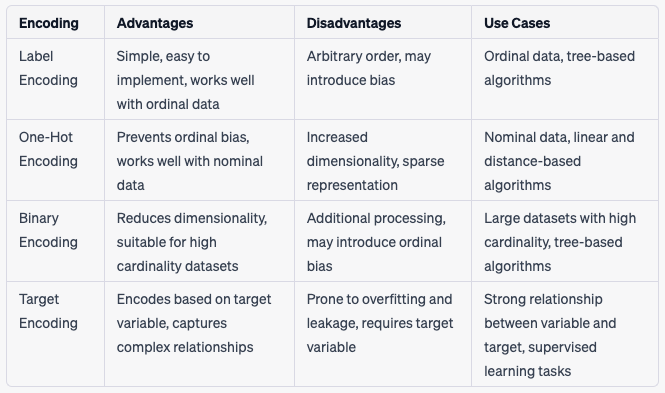

In [ ]:
from sklearn.impute import KNNImputer
import pandas as pd

def knn_impute(df, n_neighbors=5):   
    df_encoded = df.copy()
    for col in df_encoded.select_dtypes(include='object').columns:
        df_encoded[col] = df_encoded[col].astype('category').cat.codes
    knn_imputer = KNNImputer(n_neighbors=n_neighbors)
    df_imputed = pd.DataFrame(knn_imputer.fit_transform(df_encoded), columns=df_encoded.columns)
    for col in df.select_dtypes(include='object').columns:
        df_imputed[col] = df_imputed[col].round().astype(int).map(
            dict(enumerate(df[col].astype('category').cat.categories)))
    return df_imputed

In [ ]:
df_train_imputed = knn_impute(df_train, n_neighbors=5)
df_test_imputed = knn_impute(df_test, n_neighbors=5)

In [ ]:
cat_cols_train = df_train_imputed.select_dtypes(include=['object']).columns
cat_cols_train = cat_cols_train[cat_cols_train != 'class']
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

df_train_imputed[cat_cols_train] = ordinal_encoder.fit_transform(df_train_imputed[cat_cols_train].astype(str))
df_test_imputed[cat_cols_train] = ordinal_encoder.transform(df_test_imputed[cat_cols_train].astype(str))

In [ ]:
df_train_imputed.head()

In [ ]:
df_test_imputed.head()

In [ ]:
df_train = df_train_imputed
df_test = df_test_imputed

In [ ]:
df_test.head()

In [ ]:
le = LabelEncoder()
df_train['class'] = le.fit_transform(df_train['class'])

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: #7FFFD4; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 Observation from above plot :</font></h3>
    


In [ ]:
y = df_train['class'] 
X = df_train.drop(['class'],axis=1)

<p style="font-family: 'Amiri', serif; font-size: 3rem; color: black; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: cyan; padding: 20px; border-radius: 20px; border: 7px solid #2ca02c; width: 95%;">
  <span style="font-weight: bold; color: #ff7f0e; animation: pulse 2s infinite;"></span>Model Building |
  <span style="font-style: italic; color: #2ca02c; animation: pulse 2s infinite;"> Training |</span> Classification

</p>

In [ ]:
train_X, test_X, train_y, test_y = train_test_split(X, y,test_size = 0.2, random_state =42,stratify=y)

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🎇🌭Classification Analysis♒🌊</h1>  
     
</div>

In [ ]:
from sklearn.metrics import matthews_corrcoef

In [ ]:
def mcc_metric(y_pred, dmatrix):
    y_true = dmatrix.get_label()
    y_pred = (y_pred > 0.5).astype(int) 
    mcc = matthews_corrcoef(y_true, y_pred)
    return 'mcc', mcc

In [ ]:
from sklearn.metrics import matthews_corrcoef
from xgboost import XGBClassifier

model = XGBClassifier(                    
    alpha=0.1,                   
    subsample=0.8,     
    colsample_bytree=0.6,  
    objective='binary:logistic',
    max_depth=14,             
    min_child_weight=7,         
    gamma=1e-6,                
    #random_state=42,                 
    n_estimators=100
    )

XGB = model.fit(
    train_X, 
    train_y, 
    eval_set=[(test_X, test_y)],
    eval_metric=mcc_metric)

In [ ]:
y_pred = XGB.predict(test_X)

In [ ]:
import lime
import lime.lime_tabular

In [ ]:
redict_fn_xgb = lambda x: XGB.predict_proba(x).astype(float)
X = train_X.values
explainer = lime.lime_tabular.LimeTabularExplainer(X,feature_names = train_X.columns,class_names=['Poisnous','edible'],kernel_width=5)

In [ ]:
df_test.head(4)

In [ ]:
df_test.loc[[3]]

In [ ]:
test_X

In [ ]:
choosen_instance = test_X.loc[[1584520]].values[0]
exp = explainer.explain_instance(choosen_instance, redict_fn_xgb,num_features=15)
exp.show_in_notebook(show_all=False)

In [ ]:
choosen_instance = test_X.loc[[2244255]].values[0]
exp = explainer.explain_instance(choosen_instance, redict_fn_xgb,num_features=15)
exp.show_in_notebook(show_all=False)

In [ ]:
choosen_instance = test_X.loc[[421615]].values[0]
exp = explainer.explain_instance(choosen_instance, redict_fn_xgb,num_features=15)
exp.show_in_notebook(show_all=False)

In [ ]:
choosen_instance = test_X.loc[[2921070]].values[0]
exp = explainer.explain_instance(choosen_instance, redict_fn_xgb,num_features=15)
exp.show_in_notebook(show_all=False)

In [ ]:
choosen_instance = test_X.loc[[44159]].values[0]
exp = explainer.explain_instance(choosen_instance, redict_fn_xgb,num_features=15)
exp.show_in_notebook(show_all=False)

In [ ]:
score = matthews_corrcoef(test_y, y_pred)
print('MCC:', score)

In [ ]:
test_pred_prob = XGB.predict(df_test)

In [ ]:
test_pred_prob

In [ ]:
#test_pred_binary = (test_pred_prob > 0.5).astype(int)
test_pred_class = le.inverse_transform(test_pred_prob)

In [ ]:
df_sub['class']= test_pred_class

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🗞📜Final Submission♒🌊</h1>  
     
</div>

In [ ]:
df_sub.to_csv('submission.csv', index = False)
pd.read_csv('submission.csv')

In [ ]:
df_sub['class'].hist()

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: #7FFFD4; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡Refrences :</font></h3>

<div style="background-color: black; padding: 20px; border-radius: 10px; margin: 20px auto; max-width: 600px;">
    <center>
        <div style="background-color: white; padding: 20px; border-radius: 10px;">
            <b style="font-size: 24px; color: #ff6600;">👏😊 &nbsp; IF YOU FIND THIS HELPFUL, PLEASE UPVOTE! &nbsp; 💢👏</b>
            <div style="margin-top: 20px; font-size: 18px; color: black;">
                🥽🖥This took quite a bit of effort on my part, and while it might seem trivial, 🏆🏆receiving your appreciation means a lot to me! 😅🎃 Your upvotes inspire me to keep creating helpful content like this🖥🍱.                    
            </div>
        </div>
    </center>
</div>